In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('customer_churn.xls')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop('customerID', axis = 'columns', inplace=True)
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
df.TotalCharges.values

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 7043, dtype: str

In [5]:
df.MonthlyCharges.values

array([ 29.85,  56.95,  53.85, ...,  29.6 ,  74.4 , 105.65], shape=(7043,))

In [6]:
pd.to_numeric(df.TotalCharges)

ValueError: Unable to parse string " " at position 488

In [ ]:
pd.to_numeric(df.TotalCharges, errors='coerce').isnull()

In [7]:
df[pd.to_numeric(df.TotalCharges, errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
df1 = df[df.TotalCharges != ' ']
df1

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)
df1.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [10]:
df1[df.Churn == 'No'].tenure

C:\Users\Deepak\AppData\Local\Temp\ipykernel_9644\2125182133.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1[df.Churn == 'No'].tenure


0        1
1       34
3       45
6       22
7       10
        ..
7037    72
7038    24
7039    72
7040    11
7042    66
Name: tenure, Length: 5163, dtype: int64

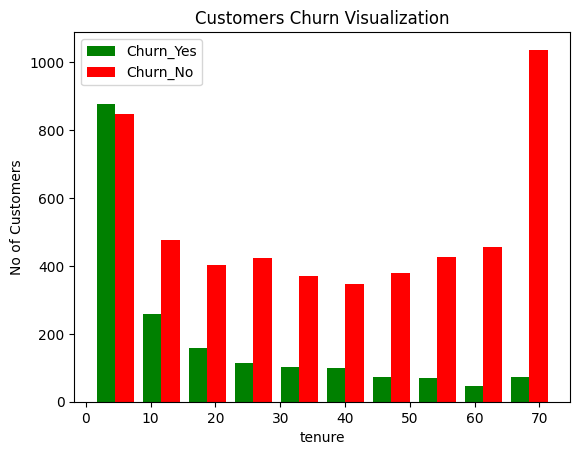

In [11]:
tenure_churn_no = df1[df1.Churn == 'No'].tenure
tenure_churn_yes = df1[df1.Churn == 'Yes'].tenure

plt.xlabel('tenure')
plt.ylabel('No of Customers')
plt.title('Customers Churn Visualization')

plt.hist([tenure_churn_yes, tenure_churn_no], color= ['green', 'red'], label = ['Churn_Yes', 'Churn_No'])
plt.legend()

In [12]:
def print_unique_col(df):
    for col in df:
        if df[col].dtypes == 'str':
            print(f' {col}: {df[col].unique()}')

In [13]:
print_unique_col(df1)

 gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
 Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
 Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
 InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
 OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
 OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
 DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
 TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
 StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
 StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
 Contract: <StringArray>
['Month-to-month', 

In [14]:
df1.replace('No internet service', 'No', inplace=True)
df1.replace('No phone service', 'No', inplace=True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [15]:
print_unique_col(df1)

 gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
 Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
 Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 MultipleLines: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
 OnlineSecurity: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 OnlineBackup: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
 DeviceProtection: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 TechSupport: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 StreamingTV: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 StreamingMovies: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
 Contract: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
 PaperlessBilling: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
 PaymentMethod: <StringArray>
[         'El

In [16]:
yes_no_col = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
             'PaperlessBilling', 'Churn', 'StreamingMovies']
for cols in yes_no_col:
    df1[cols] = df1[cols].replace({'Yes' : 1, 'No' : 0})

In [17]:
for col in df1:
    print(f' {col}: {df1[col].unique()}')

 gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
 SeniorCitizen: [0 1]
 Partner: [1 0]
 Dependents: [0 1]
 tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
 PhoneService: [0 1]
 MultipleLines: [0 1]
 InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
 OnlineSecurity: [0 1]
 OnlineBackup: [1 0]
 DeviceProtection: [0 1]
 TechSupport: [0 1]
 StreamingTV: [0 1]
 StreamingMovies: [0 1]
 Contract: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
 PaperlessBilling: [1 0]
 PaymentMethod: <StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
 MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
 TotalCharges: [  29.85 1889.5   108.15 ...  34

In [18]:
df1['gender'] = df1['gender'] = df1['gender'].replace({'Female' : 1, 'Male' : 0})

In [19]:
df1.gender.unique()

array([1, 0], dtype=object)

In [20]:
df2 = pd.get_dummies(data = df1, columns = ['InternetService', 'Contract', 'PaymentMethod'])
df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [21]:
df2.sample(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3275,1,0,1,0,14,1,0,0,0,0,...,False,False,True,False,False,True,False,False,False,True
2725,1,0,0,0,2,0,0,0,0,0,...,True,False,False,True,False,False,False,False,True,False
6836,0,1,1,0,6,1,0,0,1,0,...,False,True,False,True,False,False,False,False,True,False
1586,1,0,1,1,68,1,1,1,0,1,...,False,True,False,False,False,True,True,False,False,False


In [22]:
df2.dtypes

gender                                      object
SeniorCitizen                                int64
Partner                                     object
Dependents                                  object
tenure                                       int64
PhoneService                                object
MultipleLines                               object
OnlineSecurity                              object
OnlineBackup                                object
DeviceProtection                            object
TechSupport                                 object
StreamingTV                                 object
StreamingMovies                             object
PaperlessBilling                            object
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                       object
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No             

In [46]:

cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
        'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV',
        'StreamingMovies', 'PaperlessBilling', 'Churn']

df2[cols] = df2[cols].apply(pd.to_numeric, errors='coerce')

In [47]:
df2.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No             

In [48]:
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

df2.sample(3)

In [49]:
df2.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5584,0,0,1,0,0.140845,1,1,0,1,0,...,False,True,False,True,False,False,True,False,False,False
2460,1,0,1,1,0.661972,1,0,0,0,0,...,False,False,True,False,False,True,False,False,False,True
1713,0,0,1,0,0.718310,1,1,0,1,0,...,True,False,False,True,False,False,True,False,False,False


In [50]:
x = df2.drop('Churn', axis = 'columns')
y= df2.Churn

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2)

In [52]:
len(x_train)
len(y_train)

5625

In [53]:
len(x_test)

1407

In [58]:
model = keras.Sequential([
    keras.layers.Dense(20, input_shape= (26,), activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(5, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer = 'adam', loss= 'binary_crossentropy',
    metrics = ['accuracy']
)

model.fit(x_train, y_train, epochs=50)

Epoch 1/50


C:\Users\Deepak\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7465 - loss: 0.5055
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7924 - loss: 0.4365
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7963 - loss: 0.4261
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7995 - loss: 0.4236
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8007 - loss: 0.4184
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8039 - loss: 0.4180
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7989 - loss: 0.4161
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8023 - loss: 0.4143
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8025 - loss: 0.4134
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8075 - loss: 0.4103
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8057 - loss: 0.4100
Epoch 12/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy

In [66]:
model.evaluate(x_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7925 - loss: 0.4460 


[0.44601333141326904, 0.7924662232398987]

In [67]:
yp = model.predict(x_test)
yp[:5]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[0.49150333],
       [0.00763932],
       [0.15801041],
       [0.47882003],
       [0.00473782]], dtype=float32)

In [68]:
y_test[:5]

646     1
2659    0
5320    0
1512    0
5796    0
Name: Churn, dtype: int64

In [69]:
y_pred = []

for el in yp:
    if el > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [74]:
y_pred[:20]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0]

In [75]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.66      0.45      0.53       372

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



Text(95.72222222222221, 0.5, 'Actual')

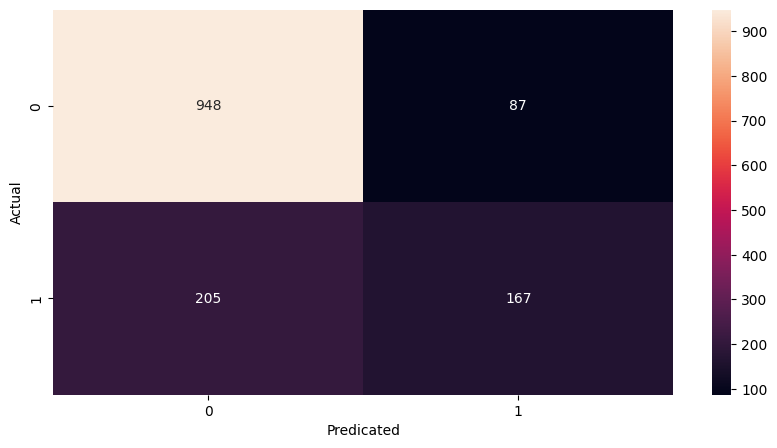

In [77]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels = y_test, predictions= y_pred)

plt.figure(figsize= (10,5))
sn.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicated')
plt.ylabel('Actual')